In [1]:
from google.colab import files
uploaded = files.upload()

Saving seeds_dataset.txt to seeds_dataset.txt


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
columns = [
    "Area",
    "Perimeter",
    "Compactness",
    "Kernel_Length",
    "Kernel_Width",
    "Asymmetry_Coefficient",
    "Groove_Length",
    "Class"
]

df= pd.read_csv(
    "seeds_dataset.txt",
    sep=r"\s+",
    header=None,
    names=columns
)


In [7]:
df.head()

,Area,Perimeter,Compactness,Kernel_Length,Kernel_Width,Asymmetry_Coefficient,Groove_Length,Class
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1


In [8]:
df.isnull().sum()

,0
Area,0
Perimeter,0
Compactness,0
Kernel_Length,0
Kernel_Width,0
Asymmetry_Coefficient,0
Groove_Length,0
Class,0


In [9]:
df.shape

(210, 8)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Area                   210 non-null    float64
 1   Perimeter              210 non-null    float64
 2   Compactness            210 non-null    float64
 3   Kernel_Length          210 non-null    float64
 4   Kernel_Width           210 non-null    float64
 5   Asymmetry_Coefficient  210 non-null    float64
 6   Groove_Length          210 non-null    float64
 7   Class                  210 non-null    int64  
dtypes: float64(7), int64(1)
memory usage: 13.3 KB


In [12]:
X = df.drop("Class", axis=1)

In [13]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

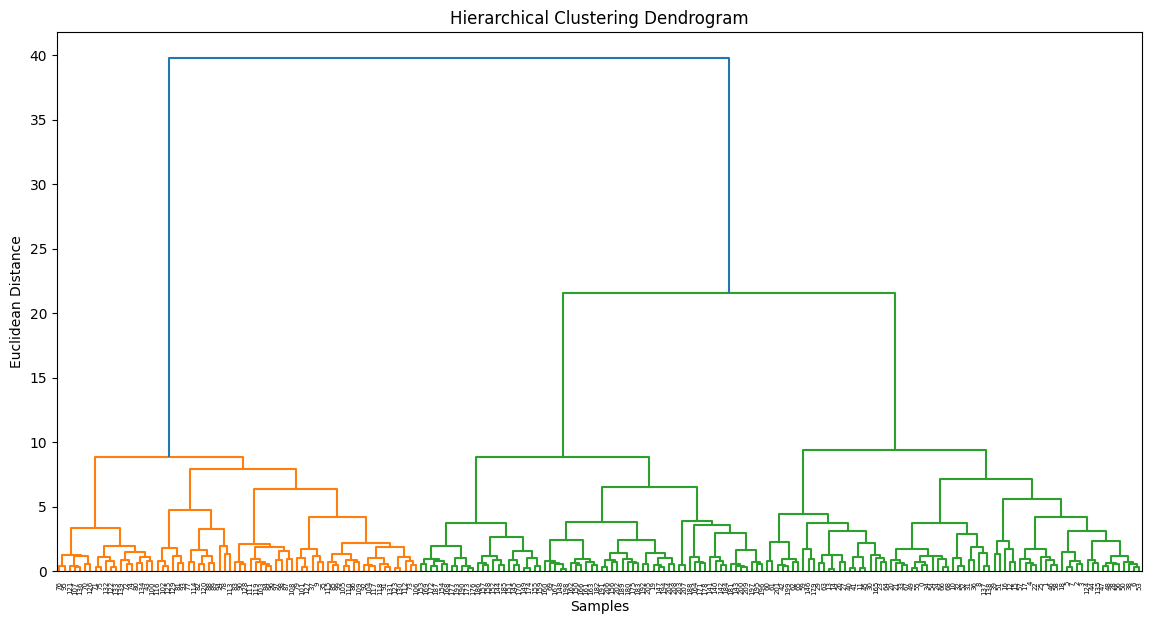

In [14]:
plt.figure(figsize=(14,7))

dendrogram(
    linkage(
        X_scaled,
        method='ward'
    )
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Euclidean Distance")
plt.show()

In [15]:
best_score = -1
best_cluster = 2

for k in range(2,8):

    model = AgglomerativeClustering(
        n_clusters=k,
        linkage='ward'
    )


In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import linkage

In [19]:
labels = model.fit_predict(X_scaled)

score = silhouette_score(
        X_scaled,
        labels
    )

print("Clusters =",k," Score =",round(score,4))

Clusters = 7  Score = 0.232


In [20]:
hc = AgglomerativeClustering(

    n_clusters=best_cluster,

    linkage='ward')

clusters = hc.fit_predict(X_scaled)

In [22]:
df["Cluster"] = clusters

In [23]:
print("\nCluster Counts\n")
print(df["Cluster"].value_counts())


Cluster Counts

Cluster
0    140
1     70
Name: count, dtype: int64


In [24]:
print("\nCluster Summary\n")

print(df.groupby("Cluster").mean())


Cluster Summary

              Area  Perimeter  Compactness  Kernel_Length  Kernel_Width  \
Cluster                                                                   
0        13.085571  13.766214     0.864298       5.363714      3.045593   
1        18.371429  16.145429     0.884400       6.158171      3.684629   

         Asymmetry_Coefficient  Groove_Length     Class  
Cluster                                                  
0                     3.730723       5.103421  2.028571  
1                     3.639157       6.017371  1.942857  


In [25]:
score = silhouette_score(
    X_scaled,
    clusters
)

print("\nFinal Silhouette Score :",score)


Final Silhouette Score : 0.4612971903388491
